In [1]:
!pip install numpy pandas matplotlib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FEATURES = [
    'TT-901', 'TT-902', 'TT-903', 'TT-904', 'PT-901', 'PT-902', 'PT-903',
    'VSD-901_CORRENT', 'VSD-901_POWER', 'VSD-901_RPM', 'VSD-901_SPEED',
    'FT-201', 'FT-801', 'FT-901',
]

# Canonical output schema — same for every row regardless of source file type.
# Extra columns in augmented files (f1_active, f1_decay, etc.) are dropped.
OUT_COLS = ['timestamp'] + FEATURES + ['is_injected_anomaly', 'anomaly_level', 'anomaly_type', 'source']

CLEAN_DIR = '/content/drive/MyDrive/THEASIS/data/processed/data_11-03_10-04/clean'
AUG_DIR   = '/content/drive/MyDrive/THEASIS/data/augmented'
OUT_DIR   = '/content/drive/MyDrive/THEASIS/data/compiled'

os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
# ---------------------------------------------------------------------------
# Load clean sessions (1-15) as normal data
# ---------------------------------------------------------------------------

all_files = sorted(glob.glob(os.path.join(CLEAN_DIR, '*.csv')))
frames = []

for path in all_files:
    session_n = int(os.path.basename(path).split('_')[2])
    if session_n in (16, 17):
        continue
    try:
        df = pd.read_csv(path, parse_dates=['timestamp'])
        if df.empty:
            print(f'Skipping empty: {os.path.basename(path)}')
            continue
        df['is_injected_anomaly'] = 0
        df['anomaly_level']       = 0
        df['anomaly_type']        = 'normal'
        df['source']              = os.path.basename(path)
        frames.append(df[OUT_COLS])
    except pd.errors.EmptyDataError:
        print(f'Skipping bad file: {os.path.basename(path)}')

normal_df = pd.concat(frames, ignore_index=True).sort_values('timestamp').reset_index(drop=True)
print(f'Normal rows (sessions 1-15): {len(normal_df):,}')

Normal rows (sessions 1-15): 29,594


In [5]:
# ---------------------------------------------------------------------------
# Fault pair definitions.
# Each entry: (key, session_16_path, session_17_path)
# For each pair, one session is randomly assigned to TRAIN, the other to TEST.
# Constraint: both sessions of the same fault type can never both be in train.
# ---------------------------------------------------------------------------

FAULT_PAIRS = [
    # --- single faults ---
    ('F1_small',
     os.path.join(AUG_DIR, 'single_faults/session_16_F1_small.csv'),
     os.path.join(AUG_DIR, 'single_faults/session_17_F1_small.csv')),
    ('F1_medium',
     os.path.join(AUG_DIR, 'single_faults/session_16_F1_medium.csv'),
     os.path.join(AUG_DIR, 'single_faults/session_17_F1_medium.csv')),
    ('F1_severe',
     os.path.join(AUG_DIR, 'single_faults/session_16_F1_severe.csv'),
     os.path.join(AUG_DIR, 'single_faults/session_17_F1_severe.csv')),
    ('F2_small',
     os.path.join(AUG_DIR, 'single_faults/session_16_F2_small.csv'),
     os.path.join(AUG_DIR, 'single_faults/session_17_F2_small.csv')),
    ('F2_medium',
     os.path.join(AUG_DIR, 'single_faults/session_16_F2_medium.csv'),
     os.path.join(AUG_DIR, 'single_faults/session_17_F2_medium.csv')),
    ('F2_severe',
     os.path.join(AUG_DIR, 'single_faults/session_16_F2_severe.csv'),
     os.path.join(AUG_DIR, 'single_faults/session_17_F2_severe.csv')),
    ('F3_small',
     os.path.join(AUG_DIR, 'single_faults/session_16_F3_small.csv'),
     os.path.join(AUG_DIR, 'single_faults/session_17_F3_small.csv')),
    ('F3_medium',
     os.path.join(AUG_DIR, 'single_faults/session_16_F3_medium.csv'),
     os.path.join(AUG_DIR, 'single_faults/session_17_F3_medium.csv')),
    ('F3_severe',
     os.path.join(AUG_DIR, 'single_faults/session_16_F3_severe.csv'),
     os.path.join(AUG_DIR, 'single_faults/session_17_F3_severe.csv')),
    ('F4_small',
     os.path.join(AUG_DIR, 'single_faults/session_16_F4_small.csv'),
     os.path.join(AUG_DIR, 'single_faults/session_17_F4_small.csv')),
    ('F4_medium',
     os.path.join(AUG_DIR, 'single_faults/session_16_F4_medium.csv'),
     os.path.join(AUG_DIR, 'single_faults/session_17_F4_medium.csv')),
    ('F4_severe',
     os.path.join(AUG_DIR, 'single_faults/session_16_F4_severe.csv'),
     os.path.join(AUG_DIR, 'single_faults/session_17_F4_severe.csv')),
    # --- combined faults ---
    ('combo_A',
     os.path.join(AUG_DIR, 'combined_faults/session_16_combo_A_F1severe_F3small.csv'),
     os.path.join(AUG_DIR, 'combined_faults/session_17_combo_A_F1severe_F3small.csv')),
    ('combo_B',
     os.path.join(AUG_DIR, 'combined_faults/session_16_combo_B_F2medium_F4severe.csv'),
     os.path.join(AUG_DIR, 'combined_faults/session_17_combo_B_F2medium_F4severe.csv')),
    # --- false positives ---
    ('fp_on_fault',
     os.path.join(AUG_DIR, 'false_positives/session_16_fp_on_F1_small_TT904.csv'),
     os.path.join(AUG_DIR, 'false_positives/session_17_fp_on_F3_severe_PT903.csv')),
    ('fp_standalone',
     os.path.join(AUG_DIR, 'false_positives/session_16_fp_standalone_TT902.csv'),
     os.path.join(AUG_DIR, 'false_positives/session_17_fp_standalone_TT903.csv')),
]

# ---------------------------------------------------------------------------
# Random assignment: for each pair, one session → TRAIN, the other → TEST.
# Change SEED to get a different split.
# ---------------------------------------------------------------------------

SEED = 42
random.seed(SEED)

train_fault_files = []   # [(key, path, session_num), ...]
test_fault_files  = []   # [(key, path, session_num), ...]

print(f'Random seed: {SEED}')
print(f'{"-"*58}')
print(f'{"Key":<20} {"→ TRAIN":>12}   {"→ TEST":>12}')
print(f'{"-"*58}')

for key, path_16, path_17 in FAULT_PAIRS:
    if random.random() < 0.5:
        train_fault_files.append((key, path_16, 16))
        test_fault_files.append((key, path_17, 17))
        print(f'{key:<20} {"session_16":>12}   {"session_17":>12}')
    else:
        train_fault_files.append((key, path_17, 17))
        test_fault_files.append((key, path_16, 16))
        print(f'{key:<20} {"session_17":>12}   {"session_16":>12}')

print(f'{"-"*58}')
print(f'Fault files → TRAIN: {len(train_fault_files)}  |  TEST: {len(test_fault_files)}')

Random seed: 42
----------------------------------------------------------
Key                       → TRAIN         → TEST
----------------------------------------------------------
F1_small               session_17     session_16
F1_medium              session_16     session_17
F1_severe              session_16     session_17
F2_small               session_16     session_17
F2_medium              session_17     session_16
F2_severe              session_17     session_16
F3_small               session_17     session_16
F3_medium              session_16     session_17
F3_severe              session_16     session_17
F4_small               session_16     session_17
F4_medium              session_16     session_17
F4_severe              session_17     session_16
combo_A                session_16     session_17
combo_B                session_16     session_17
fp_on_fault            session_17     session_16
fp_standalone          session_17     session_16
---------------------------------

In [6]:
# ---------------------------------------------------------------------------
# Build the final training CSV.
# All file types (single, combined, false positives) are read the same way:
# select only OUT_COLS — extra injection columns are ignored automatically.
# ---------------------------------------------------------------------------

fault_frames = []
for key, path, session_num in train_fault_files:
    df = pd.read_csv(path, parse_dates=['timestamp'])
    df['source'] = os.path.basename(path)
    fault_frames.append(df[OUT_COLS])

fault_df_train = pd.concat(fault_frames, ignore_index=True)

final_train_df = pd.concat([normal_df, fault_df_train], ignore_index=True)

n_normal = len(normal_df)
n_fault  = len(fault_df_train)
n_pos    = int(final_train_df['is_injected_anomaly'].sum())
n_neg    = len(final_train_df) - n_pos

print(f'Normal rows  : {n_normal:,}')
print(f'Fault rows   : {n_fault:,}')
print(f'Total rows   : {len(final_train_df):,}')
print(f'  label=0    : {n_neg:,}')
print(f'  label=1    : {n_pos:,}')
print(f'  ratio      : {n_neg/n_pos:.1f}x  (pos_weight sqrt: {(n_neg/n_pos)**0.5:.2f}x)')
print()
print('anomaly_type breakdown:')
print(final_train_df['anomaly_type'].value_counts().to_string())
print()
print('anomaly_level breakdown:')
print(final_train_df['anomaly_level'].value_counts().sort_index().to_string())

out_path = os.path.join(OUT_DIR, f'train_compiled_seed{SEED}.csv')
final_train_df.to_csv(out_path, index=False)
print(f'\nSaved → {out_path}')
print(f'Columns: {list(final_train_df.columns)}')

Normal rows  : 29,594
Fault rows   : 61,208
Total rows   : 90,802
  label=0    : 65,306
  label=1    : 25,496
  ratio      : 2.6x  (pos_weight sqrt: 1.60x)

anomaly_type breakdown:
anomaly_type
normal                                     65286
cooling_fault                               6881
valve_fault                                 5931
clogged_filters                             4064
bearing_fault                               3906
cooling_fault_decay+bearing_fault_decay     2394
clogged_filters_decay+valve_fault_decay     1997
cooling_fault+bearing_fault                  180
clogged_filters+valve_fault                  143
false_positive                                20

anomaly_level breakdown:
anomaly_level
0    82704
1     7713
2      385

Saved → /content/drive/MyDrive/THEASIS/data/compiled/train_compiled_seed42.csv
Columns: ['timestamp', 'TT-901', 'TT-902', 'TT-903', 'TT-904', 'PT-901', 'PT-902', 'PT-903', 'VSD-901_CORRENT', 'VSD-901_POWER', 'VSD-901_RPM', 'VSD-901_SPEED', 'F

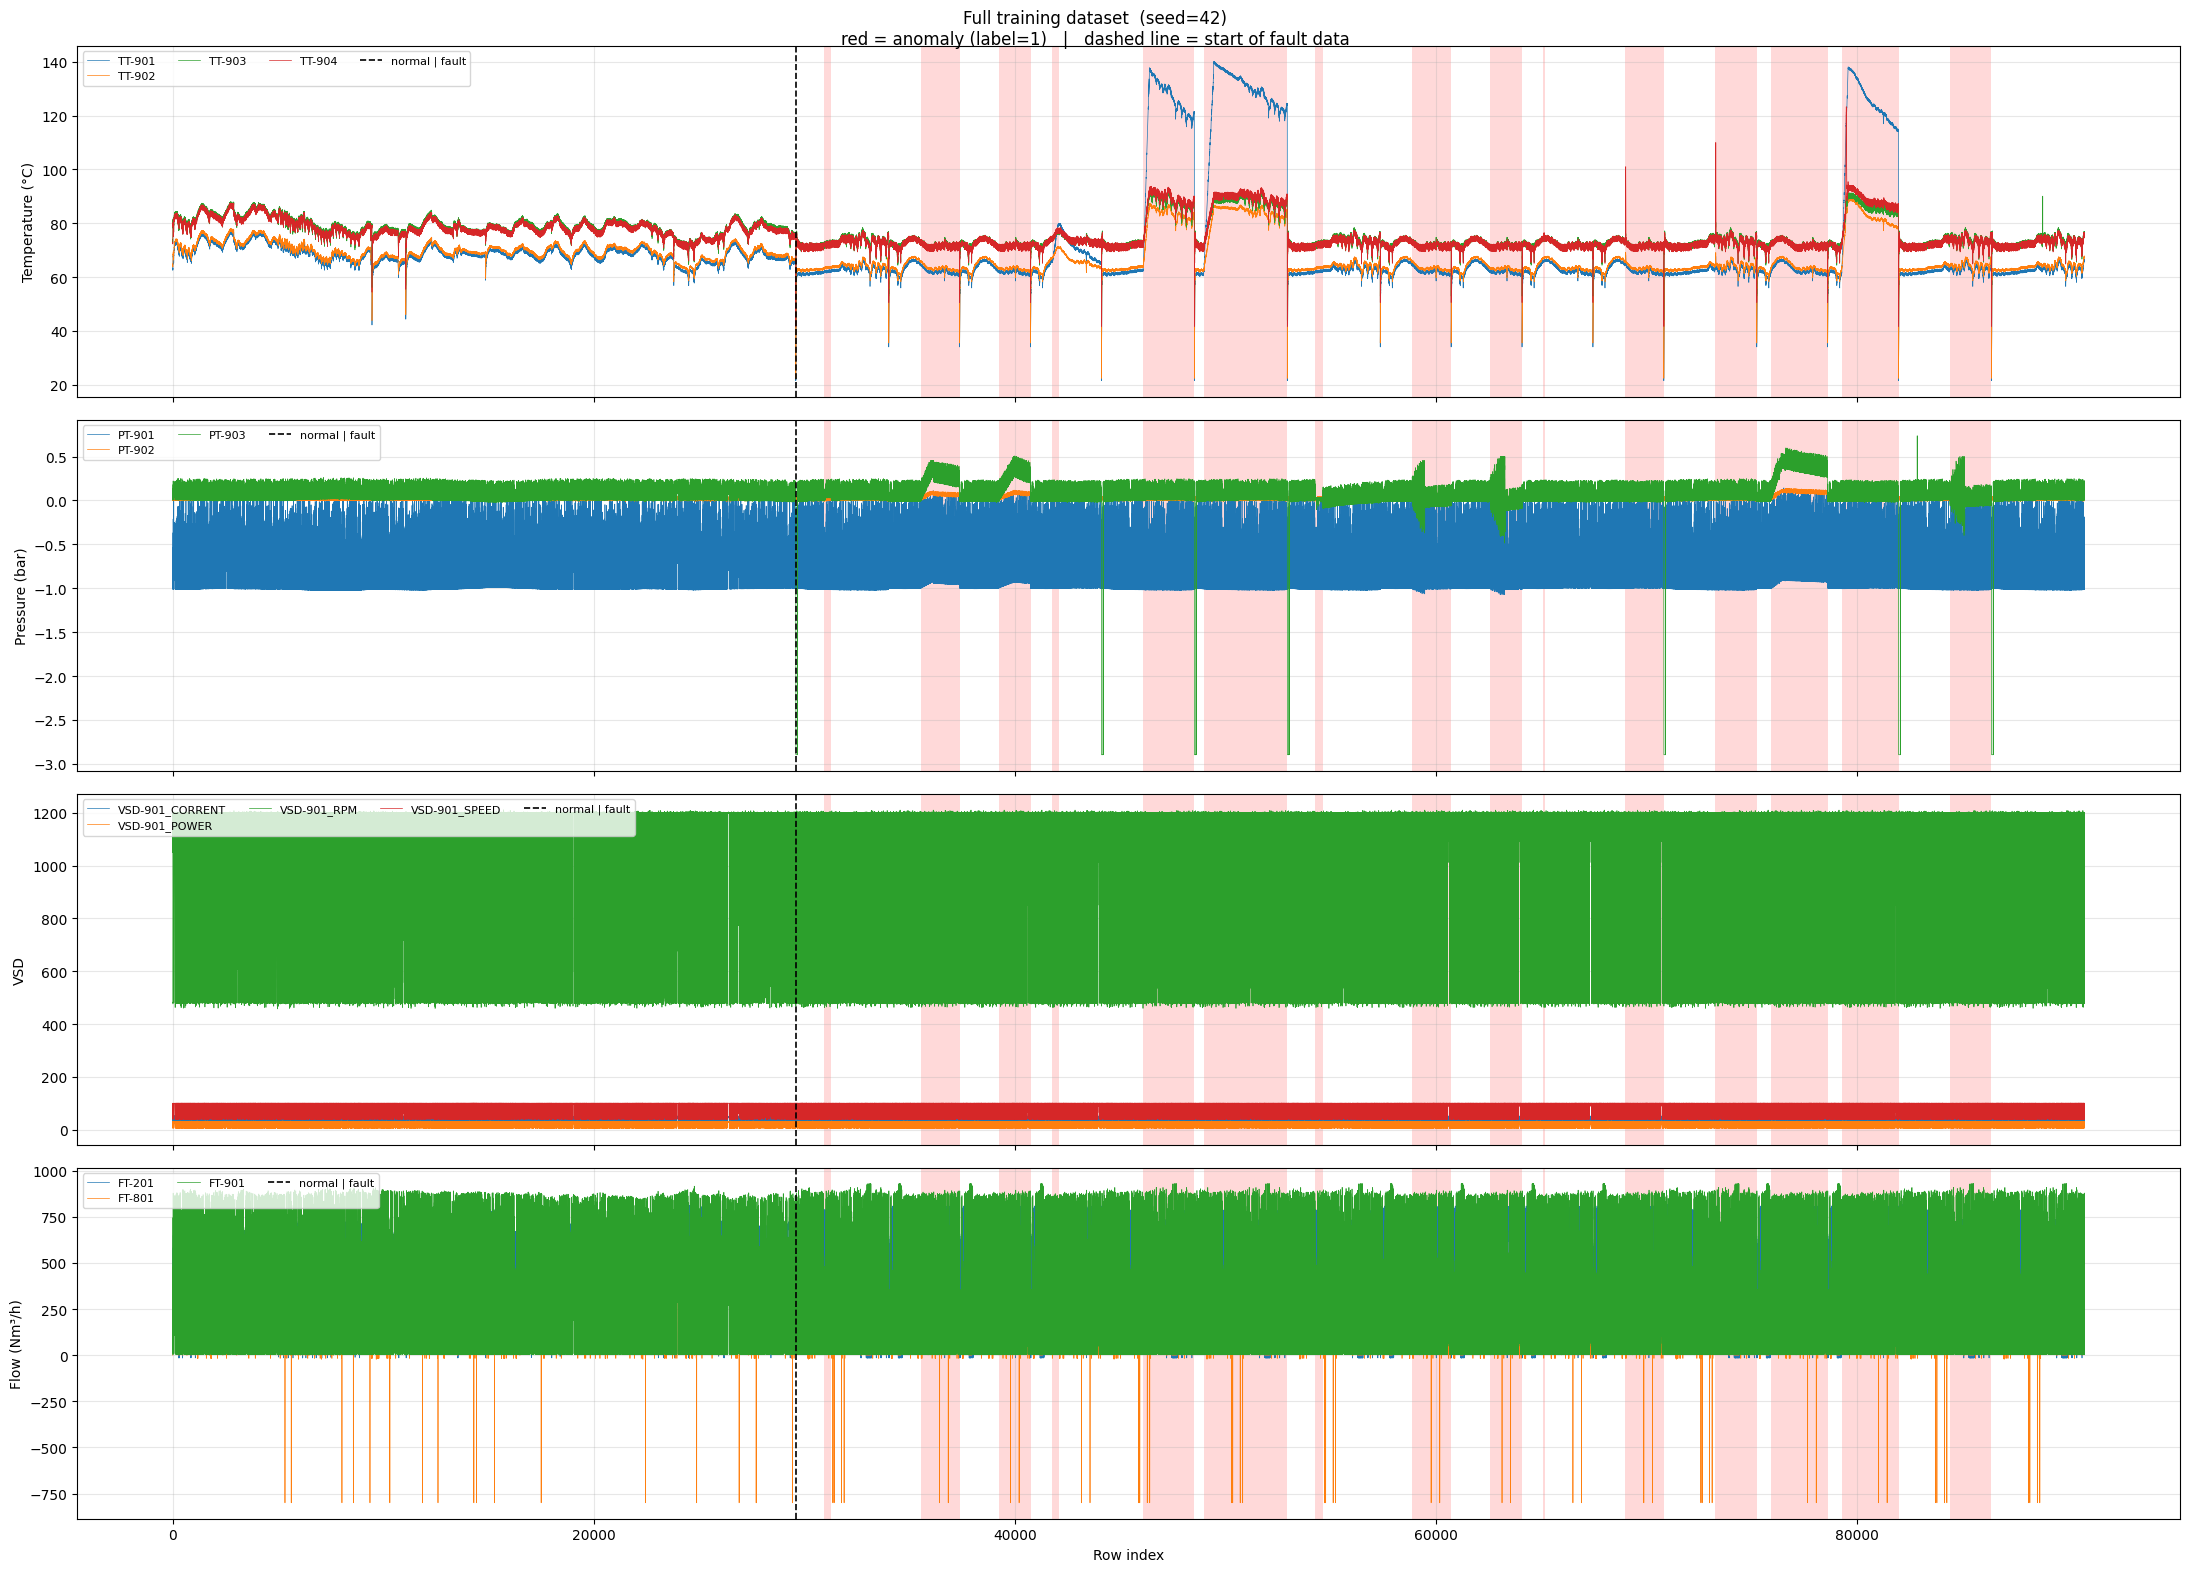

In [7]:
# ---------------------------------------------------------------------------
# Plot the entire training dataset grouped by sensor type.
# X-axis  : row index (normal rows first, fault rows appended after).
# Red shade: is_injected_anomaly == 1 regions.
# Dashed line: boundary between normal data and fault data.
# ---------------------------------------------------------------------------

SENSOR_GROUPS = {
    'Temperature (°C)': ['TT-901', 'TT-902', 'TT-903', 'TT-904'],
    'Pressure (bar)':   ['PT-901', 'PT-902', 'PT-903'],
    'VSD':              ['VSD-901_CORRENT', 'VSD-901_POWER', 'VSD-901_RPM', 'VSD-901_SPEED'],
    'Flow (Nm³/h)':     ['FT-201', 'FT-801', 'FT-901'],
}

idx     = final_train_df.index.values
anomaly = final_train_df['is_injected_anomaly'].values

# Find contiguous anomaly spans for axvspan shading
spans, in_span = [], False
for i, v in enumerate(anomaly):
    if v and not in_span:
        start, in_span = i, True
    elif not v and in_span:
        spans.append((start, i))
        in_span = False
if in_span:
    spans.append((start, len(anomaly)))

fig, axes = plt.subplots(len(SENSOR_GROUPS), 1, figsize=(22, 4 * len(SENSOR_GROUPS)), sharex=True)

for ax, (group_name, sensors) in zip(axes, SENSOR_GROUPS.items()):
    for sensor in sensors:
        ax.plot(idx, final_train_df[sensor].values, linewidth=0.5, label=sensor)

    for s, e in spans:
        ax.axvspan(s, e, color='red', alpha=0.15, linewidth=0)

    ax.axvline(n_normal, color='black', linestyle='--', linewidth=1.2, label='normal | fault')
    ax.set_ylabel(group_name, fontsize=10)
    ax.legend(fontsize=8, loc='upper left', ncol=len(sensors))
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Row index', fontsize=10)
fig.suptitle(
    f'Full training dataset  (seed={SEED})\n'
    f'red = anomaly (label=1)   |   dashed line = start of fault data',
    fontsize=12
)
plt.tight_layout()
plt.show()

In [8]:
# ---------------------------------------------------------------------------
# Test set summary
# ---------------------------------------------------------------------------

print(f'{"Key":<20} {"Session":>9}   File')
print('-' * 80)
for key, path, session_num in test_fault_files:
    print(f'{key:<20} {session_num:>9}   {os.path.basename(path)}')

print(f'\nTotal test fault files: {len(test_fault_files)}')

# TEST_FILES list ready to paste into the pipeline notebook
print('\nTEST_FILES (paste into pipeline):')
print('TEST_FILES = [')
for key, path, session_num in test_fault_files:
    print(f"    ('{session_num}_{key}', '{path}'),")
print(']')

Key                    Session   File
--------------------------------------------------------------------------------
F1_small                    16   session_16_F1_small.csv
F1_medium                   17   session_17_F1_medium.csv
F1_severe                   17   session_17_F1_severe.csv
F2_small                    17   session_17_F2_small.csv
F2_medium                   16   session_16_F2_medium.csv
F2_severe                   16   session_16_F2_severe.csv
F3_small                    16   session_16_F3_small.csv
F3_medium                   17   session_17_F3_medium.csv
F3_severe                   17   session_17_F3_severe.csv
F4_small                    17   session_17_F4_small.csv
F4_medium                   17   session_17_F4_medium.csv
F4_severe                   16   session_16_F4_severe.csv
combo_A                     17   session_17_combo_A_F1severe_F3small.csv
combo_B                     17   session_17_combo_B_F2medium_F4severe.csv
fp_on_fault                 16   session_1